# Phase 1: Data Preparation


In [6]:
%pip -q install 'numpy<3' pandas scipy scikit-learn imbalanced-learn xgboost lightgbm torch pytorch-tabnet shap matplotlib seaborn joblib streamlit openai ucimlrepo

In [7]:
import json
import os
import platform
import random
import time
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import sklearn
import xgboost as xgb

from IPython.display import display
from google.colab import drive, files
from scipy import sparse
from scipy.stats import kendalltau, loguniform
from sklearn.base import clone
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_predict,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgb.__version__)
print("LightGBM:", lgb.__version__)
print("SHAP:", shap.__version__)


Python: 3.13.15
pandas: 2.2.3
scikit-learn: 1.6.1
XGBoost: 3.4.1
LightGBM: 4.6.0
SHAP: 0.52.0


In [8]:
import torch, sys
SEED = RANDOM_STATE
torch.manual_seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 35
RUN_CNN = True
print('Deep learning device:', DEVICE)


Deep learning device: cpu


In [9]:
drive.mount('/content/drive')
PROJECT_DIR = Path('/content/drive/MyDrive/Credit_Risk_Prediction')
DATA_DIR = PROJECT_DIR / 'dataset'
OUTPUT_ROOT = PROJECT_DIR / 'outputs'
OUTPUT_DIRS = {'UCI_Credit_Card': {
    'root': OUTPUT_ROOT / 'uci_primary',
    'processed': OUTPUT_ROOT / 'uci_primary' / 'processed',
    'models': OUTPUT_ROOT / 'uci_primary' / 'models',
    'results': OUTPUT_ROOT / 'uci_primary' / 'results',
    'figures': OUTPUT_ROOT / 'uci_primary' / 'figures',
    'shap': OUTPUT_ROOT / 'uci_primary' / 'shap'}}
DEPLOY_DIR = PROJECT_DIR / 'Credit_Default_Streamlit'
ARTIFACTS = DEPLOY_DIR / 'credit_risk_artifacts'
for path in [PROJECT_DIR, DATA_DIR, OUTPUT_ROOT, DEPLOY_DIR, ARTIFACTS, *OUTPUT_DIRS['UCI_Credit_Card'].values()]:
    path.mkdir(parents=True, exist_ok=True)
CV_SPLITS = 5
SEARCH_ITERATIONS = 16
RUN_SLOW_BASELINES = False  # optional earlier SVM and KNN models
print(PROJECT_DIR, 'CV folds:', CV_SPLITS)


Mounted at /content/drive
/content/drive/MyDrive/Credit_Risk_Prediction CV folds: 5


In [10]:
def locate_or_upload(candidates, requested_name):
    # Find a dataset in Drive or request a local upload and persist it.
    for candidate in candidates:
        path = DATA_DIR / candidate
        if path.exists():
            print(f"Found: {path}")
            return path

    print(f"Missing {requested_name}. Select it in the upload dialog.")
    uploaded = files.upload() #uploaded is a dict
    if not uploaded:
        raise FileNotFoundError(f"No file uploaded for {requested_name}.")

    selected_name, content = next(iter(uploaded.items()))
    destination = DATA_DIR / requested_name
    destination.write_bytes(content)
    print(f"Saved uploaded file to: {destination}")
    return destination


UCI_PATH = locate_or_upload(['UCI_Credit_Card.csv'], 'UCI_Credit_Card.csv')


Found: /content/drive/MyDrive/Credit_Risk_Prediction/dataset/UCI_Credit_Card.csv


## Data Description

### Data Summary

| Column Name | Variable Type | Description | Values/Coding |
|-------------|---------------|-------------|---------------|
| ID | Numeric | Unique identifier for each client | Sequential client ID |
| LIMIT_BAL | Numeric | Amount of credit in NT dollars | Includes individual and family/supplementary credit |
| SEX | Categorical | Gender | 1 = Male, 2 = Female |
| EDUCATION | Categorical | Education level | 1 = Graduate school, 2 = University, 3 = High school, 4 = Others, 5 = Unknown, 6 = Unknown |
| MARRIAGE | Categorical | Marital status | 1 = Married, 2 = Single, 3 = Others |
| AGE | Numeric | Age in years | Numeric value |
| PAY_0 | Categorical | Repayment status (September 2005) | -1 = Pay duly, 1 = 1 month delay, 2 = 2 months delay, ... 8 = 8 months delay, 9 = 9+ months delay |
| PAY_2 | Categorical | Repayment status (August 2005) | Same scale as PAY_0 |
| PAY_3 | Categorical | Repayment status (July 2005) | Same scale as PAY_0 |
| PAY_4 | Categorical | Repayment status (June 2005) | Same scale as PAY_0 |
| PAY_5 | Categorical | Repayment status (May 2005) | Same scale as PAY_0 |
| PAY_6 | Categorical | Repayment status (April 2005) | Same scale as PAY_0 |
| BILL_AMT1 | Numeric | Bill statement amount (September 2005) | In NT dollars |
| BILL_AMT2 | Numeric | Bill statement amount (August 2005) | In NT dollars |
| BILL_AMT3 | Numeric | Bill statement amount (July 2005) | In NT dollars |
| BILL_AMT4 | Numeric | Bill statement amount (June 2005) | In NT dollars |
| BILL_AMT5 | Numeric | Bill statement amount (May 2005) | In NT dollars |
| BILL_AMT6 | Numeric | Bill statement amount (April 2005) | In NT dollars |
| PAY_AMT1 | Numeric | Previous payment amount (September 2005) | In NT dollars |
| PAY_AMT2 | Numeric | Previous payment amount (August 2005) | In NT dollars |
| PAY_AMT3 | Numeric | Previous payment amount (July 2005) | In NT dollars |
| PAY_AMT4 | Numeric | Previous payment amount (June 2005) | In NT dollars |
| PAY_AMT5 | Numeric | Previous payment amount (May 2005) | In NT dollars |
| PAY_AMT6 | Numeric | Previous payment amount (April 2005) | In NT dollars |
| default.payment.next.month | Categorical | Default payment indicator | 1 = Yes (default), 0 = No (no default) |

### Variable Categories Summary

| Category | Variables | Count |
|----------|-----------|-------|
| Demographic | ID, SEX, EDUCATION, MARRIAGE, AGE | 5 |
| Payment Status | PAY_0 to PAY_6 (6 months) | 6 |
| Bill Amounts | BILL_AMT1 to BILL_AMT6 (6 months) | 6 |
| Payment Amounts | PAY_AMT1 to PAY_AMT6 (6 months) | 6 |
| Target Variable | default.payment.next.month | 1 |
| **Total** | | **24 columns** |

### Variable Type Breakdown

| Variable Type | Count | Columns |
|---------------|-------|---------|
| Numeric | 12 | ID, LIMIT_BAL, AGE, BILL_AMT1-6, PAY_AMT1-6 |
| Categorical | 12 | SEX, EDUCATION, MARRIAGE, PAY_0-6, default.payment.next.month |


In [11]:
def load_uci(path):
  df = pd.read_csv(path)
  target_col = "default.payment.next.month"

  df = df.copy()
  df = df.rename(columns={target_col: "default"})
  df = df.drop(columns=["ID"])

  df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
  df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})
  df["SEX"] = df["SEX"].map({1: "male", 2: "female"}).fillna("unknown")
  df["EDUCATION"] = df["EDUCATION"].map({
      1: "graduate_school", 2: "university", 3: "high_school", 4: "other_or_unknown"
      }).fillna("other_or_unknown")
  df["MARRIAGE"] = df["MARRIAGE"].map({
      1: "married", 2: "single", 3: "other_or_unknown"
  }).fillna("other_or_unknown")
  df["default"] = pd.to_numeric(df["default"])

  if not set(df["default"].unique()).issubset({0,1}):
    raise ValueError("ICI target must contain only 0 and 1")
  return df

In [12]:
uci_raw = load_uci(UCI_PATH)
assert len(uci_raw) == 30000 and uci_raw['default'].isin([0, 1]).all()
RAW_FEATURES = uci_raw.drop(columns='default').columns.tolist()
print('UCI:', uci_raw.shape, ', raw predictors:', len(RAW_FEATURES))
display(uci_raw.head())


UCI: (30000, 24) , raw predictors: 23


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,female,university,married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000,female,university,single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000,female,university,single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000,female,university,married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000,male,university,married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [13]:
def data_quality_summary(frame):
    return {'rows': len(frame), 'predictors': frame.shape[1]-1,
            'missing_cells': int(frame.isna().sum().sum()),
            'duplicate_rows': int(frame.duplicated().sum()),
            'default_rate': float(frame['default'].mean())}
quality = pd.DataFrame([data_quality_summary(uci_raw)])
display(quality)
quality.to_csv(OUTPUT_DIRS['UCI_Credit_Card']['results'] / 'data_quality_summary.csv', index=False)


,rows,predictors,missing_cells,duplicate_rows,default_rate
0,30000,23,0,35,0.2212


## Phase 2: Exploratory Data Analysis

In [14]:
def save_and_show(path):
  path = Path(path)
  path.parent.mkdir(parents=True, exist_ok=True) #Creates the folder in which the figure will be saved.
  #parent.mkdir is figure/uci
  plt.tight_layout()
  plt.savefig(path, dpi=180, bbox_inches="tight")
  plt.show()
  plt.close()

In [15]:
uci_raw.describe(include="all").T.to_csv(
    OUTPUT_DIRS["UCI_Credit_Card"]["results"] / "descriptive_statistics.csv"
)
pd.DataFrame({
    "missing": uci_raw.isna().sum(),
    "distinct_values": uci_raw.nunique(),
}).to_csv(OUTPUT_DIRS["UCI_Credit_Card"]["results"] / "data_quality_by_feature.csv")

display(uci_raw.describe().T)

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0
PAY_6,30000.0,-0.291100,1.149988,-2.0,-1.00,0.0,0.00,8.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0


In [16]:
def target_distribution_plot(dataset_name, df):
  out = OUTPUT_DIRS[dataset_name]
  counts = df["default"].value_counts().sort_index()
  fig, ax = plt.subplots(figsize=(6,4))
  bars = ax.bar(
      ["Non-default(0)", "Default(1)"],
      counts.values,
      color=["#4C78A8", "#E67E22"],
      edgecolor="black",
      linewidth=1,
      linestyle="solid"

  )

  total = counts.sum()

  bar_labels = [
      f"{count:,}\n({count / total:.1%})"
      for count in counts.values
  ]

  ax.bar_label(bars, labels=bar_labels, padding=3)
  ax.set_ylim(0, counts.max()*1.2) #add space above bars for labels

  ax.set_title(f"{dataset_name}: Target distribution", fontsize= 12, fontweight="bold")
  ax.set_ylabel("Records", fontsize=12)
  ax.xaxis.grid(False)
  save_and_show(out["figures"] / "target_distribution.png")


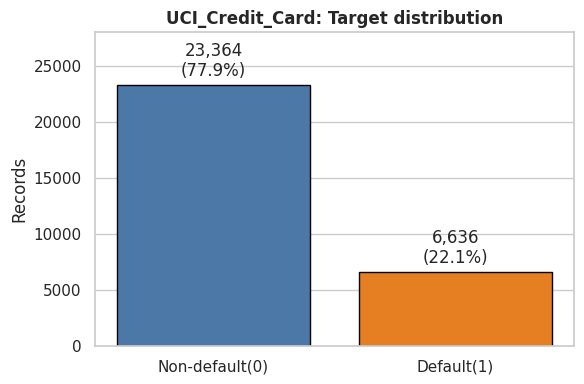

In [17]:
target_distribution_plot("UCI_Credit_Card", uci_raw)

In [18]:
def numeric_distribution_plot(dataset_name, df):
  out = OUTPUT_DIRS[dataset_name]
  numeric = df.select_dtypes(include=np.number).columns.drop("default", errors = "ignore")
  selected = list(numeric[:min(12, len(numeric))])
  df[selected].hist(figsize=(16, 10), bins=30, layout=(3, 4), color="#4C78A8", edgecolor="black", linewidth=1)
  plt.suptitle(f"{dataset_name}: selected numeric distribution", fontsize=16, fontweight="bold")
  save_and_show(out["figures"] / "numeric_distribution.png")

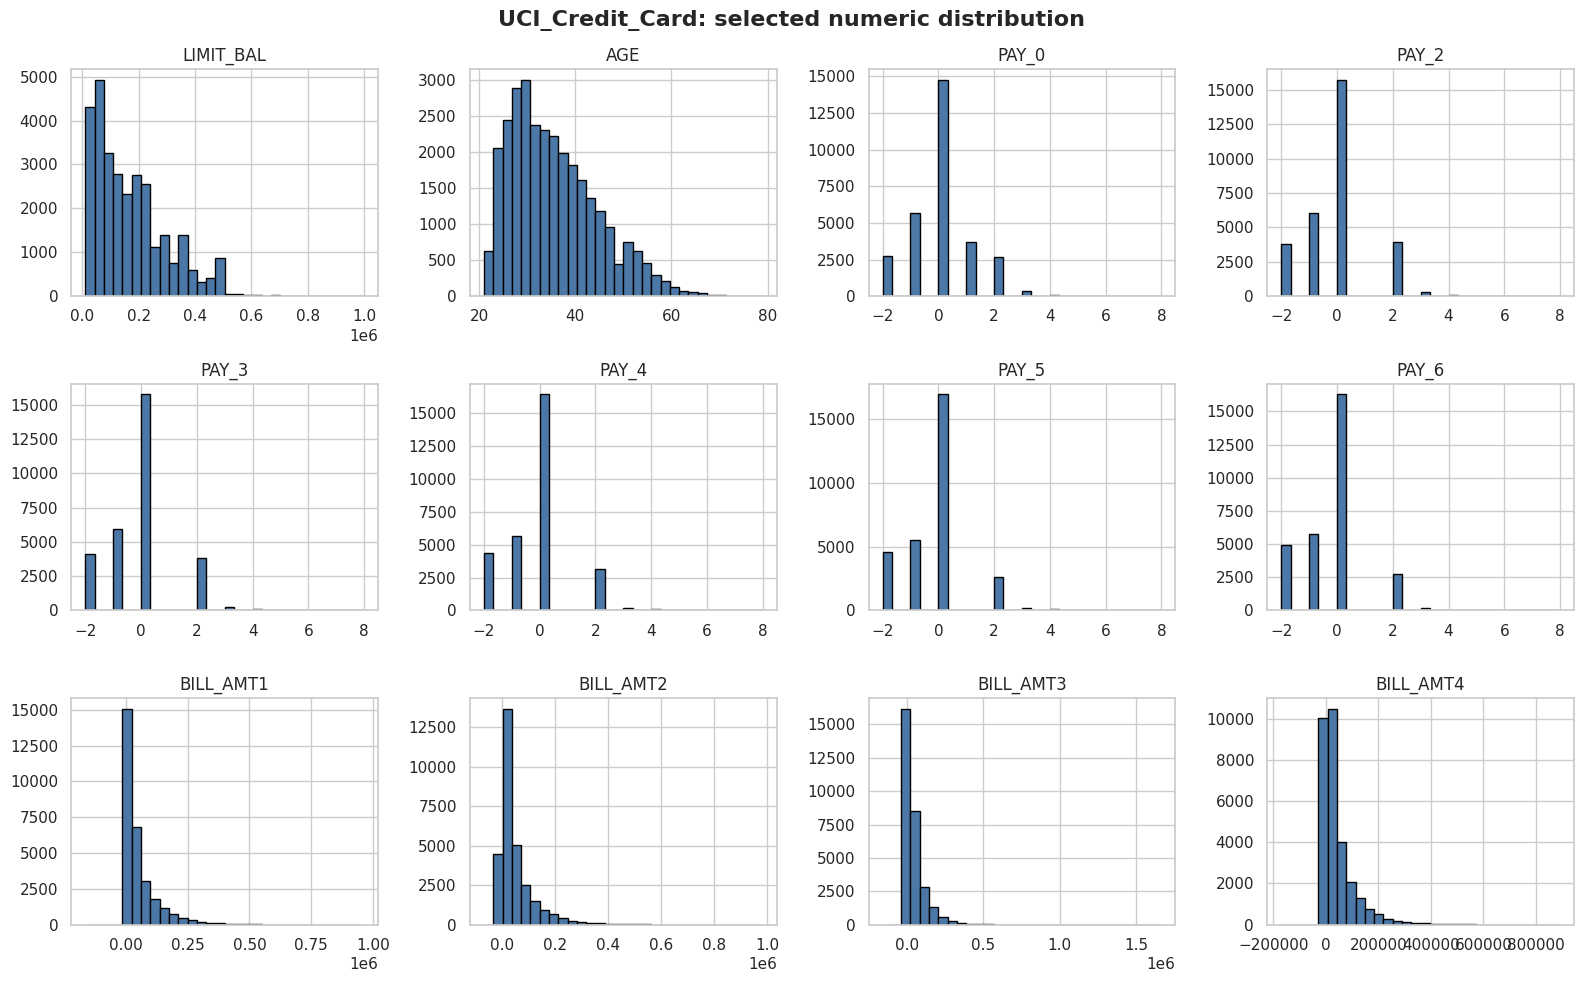

In [19]:
numeric_distribution_plot("UCI_Credit_Card", uci_raw)

In [20]:
def correlation_plot(dataset_name, df):
  out = OUTPUT_DIRS[dataset_name]
  numeric = df.select_dtypes(include=np.number).columns.drop("default", errors="ignore")
  corr = df[list(numeric) + ["default"]].corr(method="spearman")
  corr.to_csv(out["results"] / "spearman_correlation.csv")
  plt.figure(figsize=(min(18, 1+0.7 * len(corr)), min(14, 1+0.6 * len(corr))))

  sns.heatmap(
      corr,
      annot=True,
      fmt=".2f",
      annot_kws={"fontsize": 7},
      linecolor="white",
      linewidths=0.3,
      cmap="vlag",
      center=0,
      vmin=-1,
      vmax=1)

  plt.title(f"{dataset_name}: Spearman Correlation", fontsize=16, fontweight="bold")
  save_and_show(out["figures"] / "spearman_correlation.png")

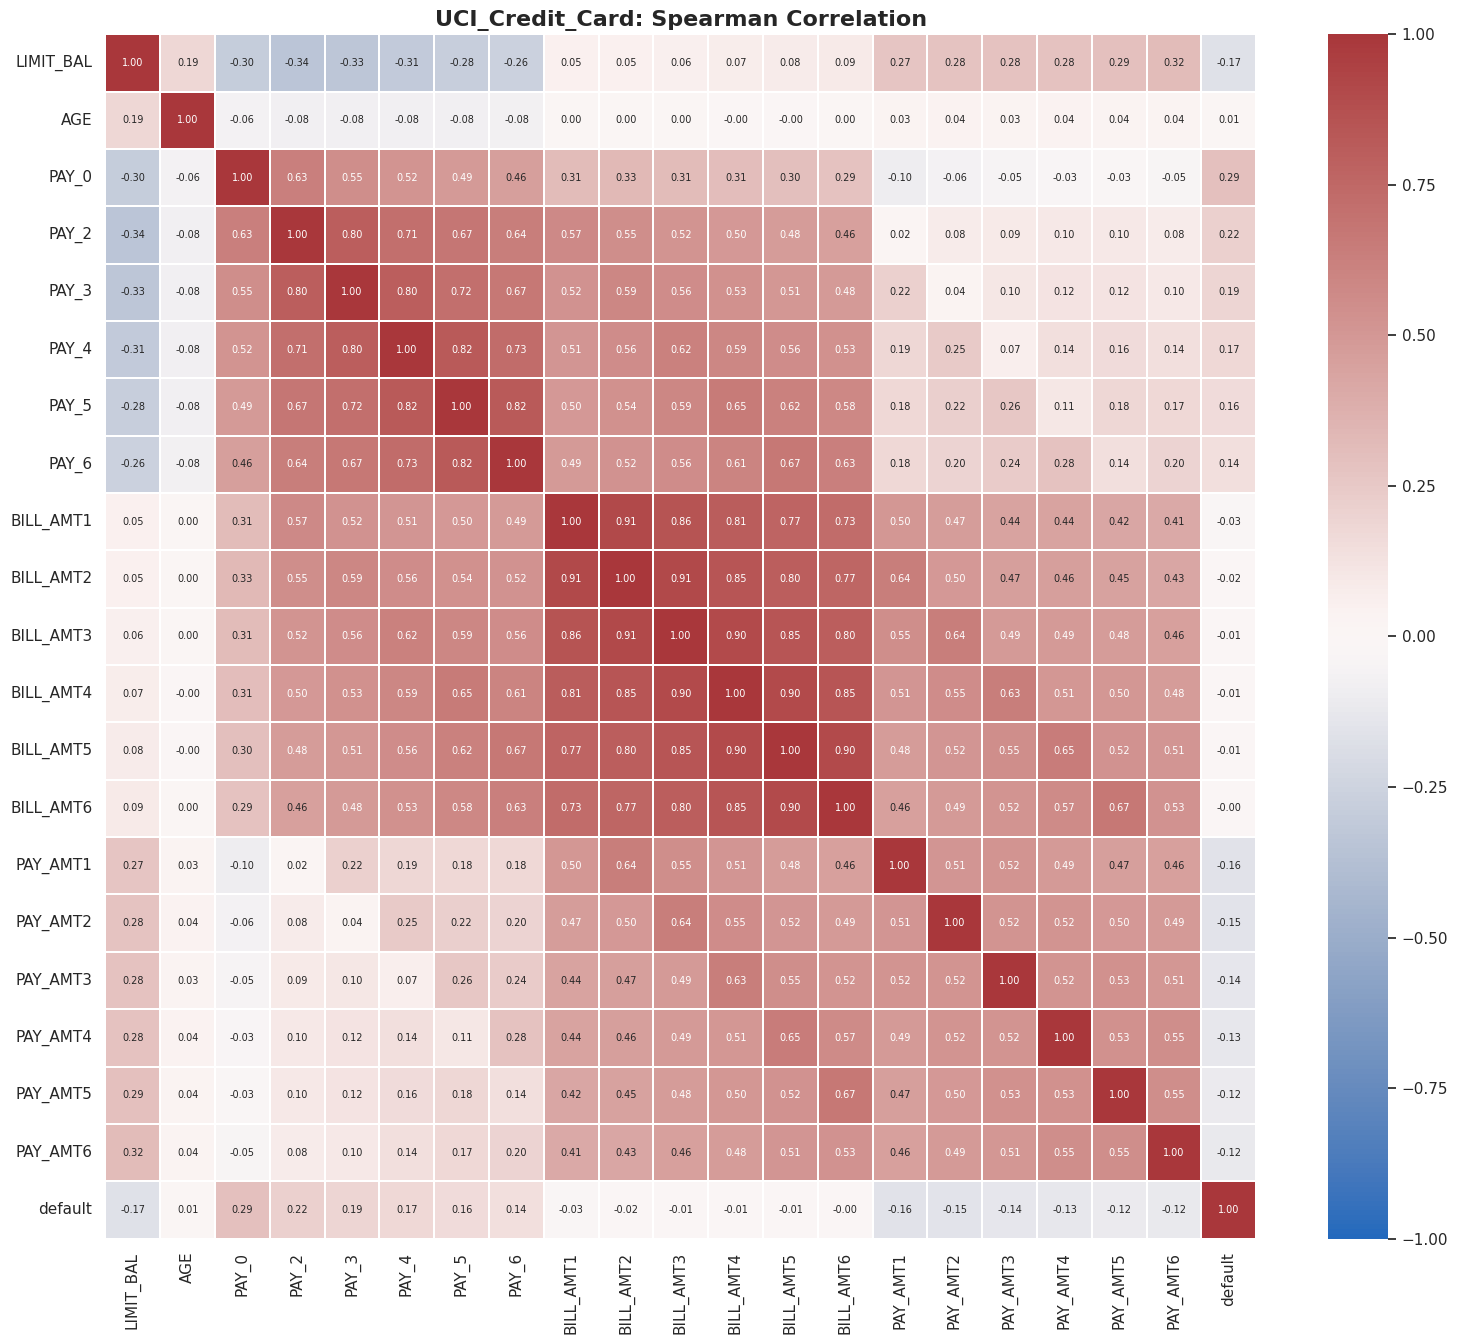

In [21]:
correlation_plot("UCI_Credit_Card", uci_raw)

In [22]:
def categorical_default_rate_plot(dataset_name, df):
  out = OUTPUT_DIRS[dataset_name]
  categorical = df.select_dtypes(exclude=np.number).columns
  if not len(categorical):
    return

  spreads = {
      col: df.groupby(col, observed=False)["default"].mean().pipe(lambda s: s.max() - s.min())
      for col in categorical
   }

  selected = sorted(spreads, key=spreads.get, reverse=True)[:8]
  fig, axes = plt.subplots(len(selected), 1, figsize=(11, 3.3 * len(selected)))
  axes = np.atleast_1d(axes)

  for ax, col in zip(axes, selected):
    rates = df.groupby(col, observed=False)["default"].agg(["mean", "count"]).sort_values("mean")
    #Only category names appear on the y-axis
    category_labels =  rates.index.astype(str)
    sns.barplot(
        x=rates["mean"],
        y=category_labels,
        ax=ax,
        color="#4C78A8",
        linewidth=1,
        edgecolor="black"
    )

    count_labels = [
        f"n = {int(count):,}"
        for count in rates["count"]
    ]

    ax.bar_label(
        ax.containers[0],
        labels=count_labels,
        label_type="edge",
        padding=4,
        fontsize=10
    )


    ax.set_title(col, fontsize=14, fontweight="bold")
    ax.set_xlabel("Default rate")
    ax.set_ylabel("")
  fig.suptitle(f"{dataset_name}: Categorical default rates", y=1.01, fontsize=15, fontweight="bold")
  save_and_show(out["figures"] / "categorical_default_rates.png")



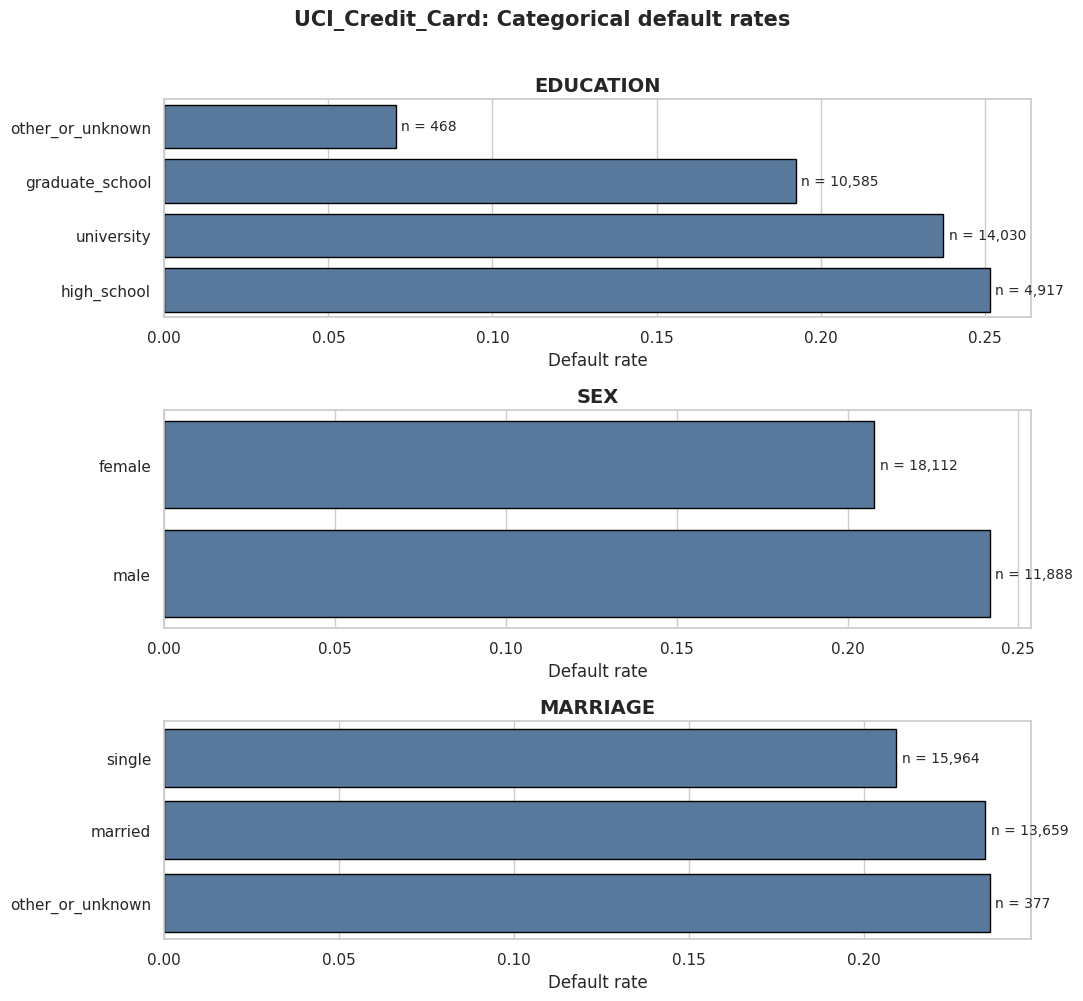

In [23]:
categorical_default_rate_plot("UCI_Credit_Card", uci_raw)

,PAY_0,mean,count
0,-2,0.132294,2759
1,-1,0.167781,5686
2,0,0.128113,14737
3,1,0.339479,3688
4,2,0.691414,2667
5,3,0.757764,322
6,4,0.684211,76
7,5,0.500000,26
8,6,0.545455,11
9,7,0.777778,9


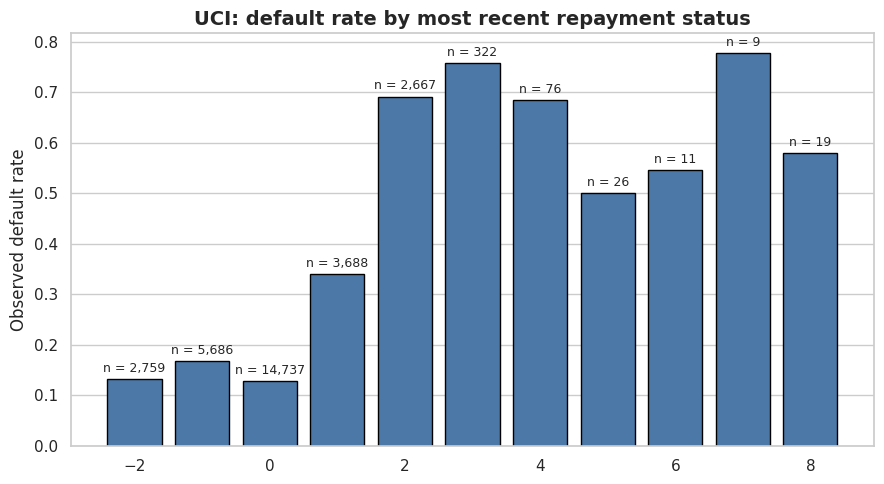

In [24]:
uci_pay_rates = uci_raw.groupby("PAY_0")["default"].agg(["mean", "count"]).reset_index()
uci_pay_rates.to_csv(
    OUTPUT_DIRS["UCI_Credit_Card"]["results"] / "default_rate_by_PAY_0.csv", index=False
)
display(uci_pay_rates)

counts = uci_pay_rates["count"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    uci_pay_rates["PAY_0"],
    uci_pay_rates["mean"],
    color="#4C78A8",
    edgecolor="black",
    linewidth=1,
)

count_labels = [
    f"n = {int(count):,}"
    for count in counts
]

ax.bar_label(bars, labels=count_labels, padding=3, fontsize=9)

ax.set_ylabel("Observed default rate")
ax.set_title("UCI: default rate by most recent repayment status", fontsize=14, fontweight="bold")
ax.xaxis.grid(False)
save_and_show(OUTPUT_DIRS["UCI_Credit_Card"]["figures"] / "default_rate_by_PAY_0.png")

# Phase 3: Feature Engineering

In [25]:
RUNTIME_SOURCE = 'import pandas as pd\nimport numpy as np\nimport torch\nfrom torch import nn\nfrom sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder\n\nENGINEERED = [\'DELAY_MONTH_COUNT\',\'SEVERE_DELAY_MONTH_COUNT\',\'MAX_REPAYMENT_STATUS\',\n    \'MEAN_REPAYMENT_STATUS\',\'REPAYMENT_STATUS_TREND\',\'TOTAL_BILL_AMT\',\'MEAN_BILL_AMT\',\n    \'BILL_AMT_VOLATILITY\',\'BILL_AMT_TREND\',\'TOTAL_PAY_AMT\',\'MEAN_PAY_AMT\',\n    \'PAY_AMT_VOLATILITY\',\'PAY_AMT_TREND\',\'CURRENT_UTILIZATION\',\'MEAN_UTILIZATION\',\n    \'PAYMENT_TO_BILL_RATIO\',\'CREDIT_HEADROOM\']\nNUMERIC = [\'LIMIT_BAL\',\'AGE\',\'PAY_0\',\'PAY_2\',\'PAY_3\',\'PAY_4\',\'PAY_5\',\'PAY_6\'] + [f\'BILL_AMT{i}\' for i in range(1,7)] + [f\'PAY_AMT{i}\' for i in range(1,7)] + ENGINEERED\nCATEGORICAL = [\'SEX\',\'EDUCATION\',\'MARRIAGE\']\nSTATIC_NUMERIC = [\'LIMIT_BAL\',\'AGE\']\nSTATIC_CATEGORICAL = [\'SEX\',\'EDUCATION\',\'MARRIAGE\']\nPAY_STATUS = [\'PAY_0\',\'PAY_2\',\'PAY_3\',\'PAY_4\',\'PAY_5\',\'PAY_6\']\nMONTHLY = PAY_STATUS + [f\'BILL_AMT{i}\' for i in range(1,7)] + [f\'PAY_AMT{i}\' for i in range(1,7)]\n\ndef signed_log(values):\n    return np.sign(values) * np.log1p(np.abs(values))\n\nclass NeuralPreprocessor:\n    def fit(self, frame):\n        n = self._num(frame)\n        self.num_medians = np.nanmedian(n,axis=0)\n        self.num_scaler = StandardScaler().fit(np.where(np.isnan(n),self.num_medians,n))\n        self.cat_encoder = OrdinalEncoder(handle_unknown=\'use_encoded_value\',unknown_value=-1).fit(frame[CATEGORICAL].astype(str))\n        self.onehot = OneHotEncoder(handle_unknown=\'ignore\',sparse_output=False).fit(frame[CATEGORICAL].astype(str))\n        self.static_onehot = OneHotEncoder(handle_unknown=\'ignore\',sparse_output=False).fit(frame[STATIC_CATEGORICAL].astype(str))\n        self.static_scaler = StandardScaler().fit(self._static_num(frame))\n        self.seq_scaler = StandardScaler().fit(self._sequence(frame).reshape(-1,3))\n        self.cat_sizes = [len(v)+1 for v in self.cat_encoder.categories_]\n        example = self.transform(frame.iloc[:1])\n        self.dense_dim = example[\'dense\'].shape[1]\n        self.static_dim = example[\'static\'].shape[1]\n        return self\n\n    def _num(self, frame):\n        values = frame[NUMERIC].to_numpy(dtype=float).copy()\n        money = [0] + list(range(8,20)) + [NUMERIC.index(n) for n in\n            [\'TOTAL_BILL_AMT\',\'MEAN_BILL_AMT\',\'BILL_AMT_VOLATILITY\',\'BILL_AMT_TREND\',\n             \'TOTAL_PAY_AMT\',\'MEAN_PAY_AMT\',\'PAY_AMT_VOLATILITY\',\'PAY_AMT_TREND\',\'CREDIT_HEADROOM\']]\n        values[:,money] = signed_log(values[:,money])\n        return values\n\n    def _static_num(self, frame):\n        v=frame[STATIC_NUMERIC].to_numpy(dtype=float).copy(); v[:,0]=signed_log(v[:,0]); return v\n\n    def _sequence(self, frame):\n        p=frame[PAY_STATUS].to_numpy(dtype=float)\n        b=signed_log(frame[[f\'BILL_AMT{i}\' for i in range(1,7)]].to_numpy(dtype=float))\n        a=signed_log(frame[[f\'PAY_AMT{i}\' for i in range(1,7)]].to_numpy(dtype=float))\n        return np.stack([p,b,a],axis=-1)  # N x 6 months (latest first) x 3 signals\n\n    def transform(self, frame):\n        raw=self._num(frame)\n        num=self.num_scaler.transform(np.where(np.isnan(raw),self.num_medians,raw)).astype(\'float32\')\n        cat=(self.cat_encoder.transform(frame[CATEGORICAL].astype(str)).astype(\'int64\')+1)\n        dense=np.hstack([num,self.onehot.transform(frame[CATEGORICAL].astype(str))]).astype(\'float32\')\n        static=np.hstack([self.static_scaler.transform(self._static_num(frame)),\n                          self.static_onehot.transform(frame[STATIC_CATEGORICAL].astype(str))]).astype(\'float32\')\n        seq=self.seq_scaler.transform(self._sequence(frame).reshape(-1,3)).reshape(-1,6,3)\n        return {\'num\':num,\'cat\':cat,\'dense\':dense,\'static\':static,\'seq\':seq.astype(\'float32\')}\n\nclass ResidualBlock(nn.Module):\n    def __init__(self,width):\n        super().__init__(); self.net=nn.Sequential(nn.Linear(width,width),nn.ReLU(),nn.Dropout(.15),nn.Linear(width,width))\n    def forward(self,x): return torch.relu(x+self.net(x))\n\nclass DenseModel(nn.Module):\n    def __init__(self,dense_dim,residual=False):\n        super().__init__()\n        self.net=(nn.Sequential(nn.Linear(dense_dim,128),nn.ReLU(),ResidualBlock(128),ResidualBlock(128),nn.Linear(128,1))\n                  if residual else nn.Sequential(nn.Linear(dense_dim,128),nn.ReLU(),nn.Dropout(.2),nn.Linear(128,64),nn.ReLU(),nn.Linear(64,1)))\n    def forward(self,b): return self.net(b[\'dense\']).squeeze(-1)\n\nclass FTTransformer(nn.Module):\n    def __init__(self,n_num,cat_sizes,width=32):\n        super().__init__(); self.n_num=n_num\n        self.num_weight=nn.Parameter(torch.randn(n_num,width)*.02)\n        self.num_bias=nn.Parameter(torch.zeros(n_num,width))\n        self.cat_embeddings=nn.ModuleList([nn.Embedding(size,width) for size in cat_sizes])\n        self.cls=nn.Parameter(torch.zeros(1,1,width))\n        layer=nn.TransformerEncoderLayer(d_model=width,nhead=4,dim_feedforward=128,dropout=.1,batch_first=True)\n        self.transformer=nn.TransformerEncoder(layer,num_layers=2)\n        self.head=nn.Sequential(nn.LayerNorm(width),nn.Linear(width,1))\n    def forward(self,b):\n        num_tokens=b[\'num\'].unsqueeze(-1)*self.num_weight+self.num_bias\n        cat_tokens=torch.stack([emb(b[\'cat\'][:,i]) for i,emb in enumerate(self.cat_embeddings)],dim=1)\n        tokens=torch.cat([self.cls.expand(len(num_tokens),-1,-1),num_tokens,cat_tokens],dim=1)\n        return self.head(self.transformer(tokens)[:,0]).squeeze(-1)\n\nclass MonthlyCNN(nn.Module):\n    def __init__(self,static_dim):\n        super().__init__(); self.conv=nn.Sequential(nn.Conv1d(3,16,3,padding=1),nn.ReLU(),nn.Conv1d(16,32,3,padding=1),nn.ReLU(),nn.AdaptiveAvgPool1d(1))\n        self.head=nn.Sequential(nn.Linear(32+static_dim,64),nn.ReLU(),nn.Dropout(.2),nn.Linear(64,1))\n    def forward(self,b): return self.head(torch.cat([self.conv(b[\'seq\'].transpose(1,2)).squeeze(-1),b[\'static\']],dim=1)).squeeze(-1)\n\ndef make_network(name,prep):\n    if name==\'MLP\': return DenseModel(prep.dense_dim)\n    if name==\'Tabular ResNet\': return DenseModel(prep.dense_dim,residual=True)\n    if name==\'FT-Transformer\': return FTTransformer(len(NUMERIC),prep.cat_sizes)\n    if name==\'1D-CNN\': return MonthlyCNN(prep.static_dim)\n    raise ValueError(name)\n\n@torch.no_grad()\ndef torch_probability(network,encoded,device=\'cpu\',batch_size=1024):\n    network.to(device).eval(); pieces=[]\n    for start in range(0,len(encoded[\'dense\']),batch_size):\n        batch={k:torch.as_tensor(v[start:start+batch_size],device=device) for k,v in encoded.items()}\n        pieces.append(torch.sigmoid(network(batch)).cpu().numpy())\n    return np.concatenate(pieces)\ndef safe_ratio(numerator, denominator, lower=-10, upper=10):\n    denominator = np.where(np.abs(denominator) < 1e-9, np.nan, denominator)\n    ratio = np.asarray(numerator, dtype=float) / denominator\n    return np.clip(ratio, lower, upper)\n\n\ndef add_uci_features(df):\n    result = df.copy()\n    for column in result.columns.difference([\'SEX\',\'EDUCATION\',\'MARRIAGE\',\'default\']):\n        result[column] = pd.to_numeric(result[column],errors=\'raise\')\n    pay_status = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]\n    bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]\n    payment_cols = [f"PAY_AMT{i}" for i in range(1, 7)]\n\n    result["DELAY_MONTH_COUNT"] = (result[pay_status] > 0).sum(axis=1)\n    result["SEVERE_DELAY_MONTH_COUNT"] = (result[pay_status] >= 2).sum(axis=1)\n    result["MAX_REPAYMENT_STATUS"] = result[pay_status].max(axis=1)\n    result["MEAN_REPAYMENT_STATUS"] = result[pay_status].mean(axis=1)\n    result["REPAYMENT_STATUS_TREND"] = result["PAY_0"] - result["PAY_6"]\n\n    result["TOTAL_BILL_AMT"] = result[bill_cols].sum(axis=1)\n    result["MEAN_BILL_AMT"] = result[bill_cols].mean(axis=1)\n    result["BILL_AMT_VOLATILITY"] = result[bill_cols].std(axis=1)\n    result["BILL_AMT_TREND"] = result["BILL_AMT1"] - result["BILL_AMT6"]\n\n    result["TOTAL_PAY_AMT"] = result[payment_cols].sum(axis=1)\n    result["MEAN_PAY_AMT"] = result[payment_cols].mean(axis=1)\n    result["PAY_AMT_VOLATILITY"] = result[payment_cols].std(axis=1)\n    result["PAY_AMT_TREND"] = result["PAY_AMT1"] - result["PAY_AMT6"]\n\n    result["CURRENT_UTILIZATION"] = safe_ratio(result["BILL_AMT1"], result["LIMIT_BAL"])\n    result["MEAN_UTILIZATION"] = safe_ratio(result["MEAN_BILL_AMT"], result["LIMIT_BAL"])\n    result["PAYMENT_TO_BILL_RATIO"] = safe_ratio(\n        result["TOTAL_PAY_AMT"], np.abs(result["TOTAL_BILL_AMT"]) + 1\n    )\n    result["CREDIT_HEADROOM"] = result["LIMIT_BAL"] - result["BILL_AMT1"]\n    return result\n'
runtime_path = DEPLOY_DIR / 'credit_risk_runtime.py'
runtime_path.write_text(RUNTIME_SOURCE)
sys.path.insert(0,str(DEPLOY_DIR))
from credit_risk_runtime import (add_uci_features, NeuralPreprocessor, make_network,
    torch_probability, NUMERIC, CATEGORICAL, signed_log)
print('Shared feature engineering and model definitions:',runtime_path)


Shared feature engineering and model definitions: /content/drive/MyDrive/Credit_Risk_Prediction/Credit_Default_Streamlit/credit_risk_runtime.py


In [26]:
uci = add_uci_features(uci_raw)
MODEL_FEATURES = uci.drop(columns='default').columns.tolist()
uci.to_csv(OUTPUT_DIRS['UCI_Credit_Card']['processed'] / 'model_ready.csv',
           index=True,index_label='source_row_index')
assert uci['default'].equals(uci_raw['default'])
display(pd.DataFrame([{'raw_predictors':len(RAW_FEATURES),
                       'model_predictors':len(MODEL_FEATURES)}]))


,raw_predictors,model_predictors
0,23,40


# Phase 4: Model Development

In [27]:
from sklearn.model_selection import train_test_split
X, y = uci.drop(columns='default'), uci['default'].astype(int)
X_dev, X_test, y_dev, y_test = train_test_split(X,y,test_size=.20,stratify=y,random_state=SEED)
X_train, X_rest, y_train, y_rest = train_test_split(X_dev,y_dev,test_size=.25,stratify=y_dev,random_state=SEED)
X_val, X_cal, y_val, y_cal = train_test_split(X_rest,y_rest,test_size=.50,stratify=y_rest,random_state=SEED)
for name, xx, yy in [('train',X_train,y_train),('validation',X_val,y_val),('calibration',X_cal,y_cal),('test',X_test,y_test)]:
    print(f'{name:12} n={len(xx):5d} default_rate={yy.mean():.3f}')

train        n=18000 default_rate=0.221
validation   n= 3000 default_rate=0.221
calibration  n= 3000 default_rate=0.221
test         n= 6000 default_rate=0.221


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from credit_risk_runtime import NUMERIC, CATEGORICAL, signed_log, NeuralPreprocessor, make_network, torch_probability

scale_prep=ColumnTransformer([
    ('num',Pipeline([('impute',SimpleImputer(strategy='median')),('log',FunctionTransformer(signed_log,feature_names_out='one-to-one')),('scale',StandardScaler())]),NUMERIC),
    ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),CATEGORICAL)])
tree_prep=ColumnTransformer([('num',SimpleImputer(strategy='median'),NUMERIC),('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),CATEGORICAL)])
ratio=(y_train==0).sum()/(y_train==1).sum()
models={
 'Dummy': Pipeline([('prep',tree_prep),('clf',DummyClassifier(strategy='prior'))]),
 'Logistic Regression': Pipeline([('prep',scale_prep),('clf',LogisticRegression(max_iter=1000,class_weight='balanced'))]),
 'Random Forest': Pipeline([('prep',tree_prep),('clf',RandomForestClassifier(n_estimators=250,class_weight='balanced_subsample',n_jobs=-1,random_state=SEED))]),
 'XGBoost': Pipeline([('prep',tree_prep),('clf',XGBClassifier(n_estimators=350,tree_method='hist',eval_metric='logloss',scale_pos_weight=ratio,n_jobs=2,random_state=SEED))]),
 'LightGBM': Pipeline([('prep',tree_prep),('clf',LGBMClassifier(n_estimators=350,class_weight='balanced',verbosity=-1,n_jobs=2,random_state=SEED))])}
if RUN_SLOW_BASELINES:
    models['SVM']=Pipeline([('prep',scale_prep),('clf',SVC(probability=True,class_weight='balanced',random_state=SEED))])
    models['KNN']=Pipeline([('prep',scale_prep),('clf',KNeighborsClassifier())])
spaces={
 'Logistic Regression':{'clf__C':[.03,.1,.3,1,3]},
 'Random Forest':{'clf__max_depth':[6,10,None],'clf__min_samples_leaf':[2,5,10]},
 'XGBoost':{'clf__max_depth':[3,5],'clf__learning_rate':[.03,.06,.1],'clf__min_child_weight':[1,5]},
 'LightGBM':{'clf__num_leaves':[15,31],'clf__learning_rate':[.03,.06,.1],'clf__min_child_samples':[20,50]},
 'SVM':{'clf__C':[.1,1,10],'clf__gamma':['scale',.01]},
 'KNN':{'clf__n_neighbors':[9,21,51],'clf__weights':['uniform','distance']}}
cv=StratifiedKFold(n_splits=CV_SPLITS,shuffle=True,random_state=RANDOM_STATE)
fitted={}; rows=[]
for name, estimator in models.items():
    if name=='Dummy':
        fitted[name]=estimator.fit(X_train,y_train); cv_score=np.nan
    else:
        search=RandomizedSearchCV(estimator,spaces[name],n_iter=SEARCH_ITERATIONS,scoring='average_precision',cv=cv,
                                  n_jobs=1,random_state=SEED,refit=True,error_score='raise')
        search.fit(X_train,y_train); fitted[name]=search.best_estimator_; cv_score=search.best_score_
    p=fitted[name].predict_proba(X_val)[:,1]
    rows.append({'Model':name,'Family':'ML','CV PR-AUC':cv_score,'Validation PR-AUC':average_precision_score(y_val,p),
                 'Validation ROC-AUC':roc_auc_score(y_val,p)})
    print(name, 'validation PR-AUC:',round(rows[-1]['Validation PR-AUC'],4))

Dummy validation PR-AUC: 0.2213


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=16. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Logistic Regression validation PR-AUC: 0.496


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=16. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Random Forest validation PR-AUC: 0.5426


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=16. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


XGBoost validation PR-AUC: 0.5466


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=16. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr

LightGBM validation PR-AUC: 0.5468


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [29]:
from sklearn.metrics import average_precision_score
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pytorch_tabnet.tab_model import TabNetClassifier

nn_prep=NeuralPreprocessor().fit(X_train)
train_enc=nn_prep.transform(X_train); val_enc=nn_prep.transform(X_val)

class EncodedDataset(Dataset):
    def __init__(self,encoded,labels): self.encoded=encoded; self.labels=np.asarray(labels,dtype='float32')
    def __len__(self): return len(self.labels)
    def __getitem__(self,index):
        return {key:torch.as_tensor(values[index]) for key,values in self.encoded.items()},torch.tensor(self.labels[index])

train_loader=DataLoader(EncodedDataset(train_enc,y_train),batch_size=512,shuffle=True,num_workers=0)
neural={}; neural_history={}
for name in ['MLP','Tabular ResNet','FT-Transformer']+(['1D-CNN'] if RUN_CNN else []):
    net=make_network(name,nn_prep).to(DEVICE)
    opt=torch.optim.AdamW(net.parameters(),lr=.001,weight_decay=.001)
    loss_fn=nn.BCEWithLogitsLoss(pos_weight=torch.tensor(ratio,device=DEVICE,dtype=torch.float32))
    best=-1; patience=7; wait=0; history=[]; state=None
    for epoch in range(EPOCHS):
        net.train()
        for xb,yb in train_loader:
            xb={k:v.to(DEVICE) for k,v in xb.items()}; yb=yb.to(DEVICE)
            opt.zero_grad(); loss=loss_fn(net(xb),yb); loss.backward(); opt.step()
        score=average_precision_score(y_val,torch_probability(net,val_enc,DEVICE))
        history.append(score)
        if score>best+1e-4:
            best=score; state={k:v.detach().cpu().clone() for k,v in net.state_dict().items()}; wait=0
        else: wait+=1
        if wait>=patience: break
    net.load_state_dict(state); net.cpu(); neural[name]=net; neural_history[name]=history
    p=torch_probability(net,val_enc)
    rows.append({'Model':name,'Family':'Deep learning','CV PR-AUC':np.nan,'Validation PR-AUC':average_precision_score(y_val,p),
                 'Validation ROC-AUC':roc_auc_score(y_val,p)})
    print(name,'epochs:',len(history),'best validation PR-AUC:',round(best,4))

tabnet=TabNetClassifier(n_d=16,n_a=16,n_steps=3,seed=SEED,verbose=0,device_name=DEVICE)
tabnet.fit(train_enc['dense'],y_train.to_numpy(),eval_set=[(val_enc['dense'],y_val.to_numpy())],
           eval_metric=['auc'],max_epochs=EPOCHS,patience=7,batch_size=1024,virtual_batch_size=128,
           weights={0:1.,1:float(ratio)},num_workers=0)
neural['TabNet']=tabnet
p=tabnet.predict_proba(val_enc['dense'])[:,1]
rows.append({'Model':'TabNet','Family':'Deep learning','CV PR-AUC':np.nan,'Validation PR-AUC':average_precision_score(y_val,p),
             'Validation ROC-AUC':roc_auc_score(y_val,p)})

MLP epochs: 33 best validation PR-AUC: 0.5434
Tabular ResNet epochs: 18 best validation PR-AUC: 0.5362
FT-Transformer epochs: 22 best validation PR-AUC: 0.5315
1D-CNN epochs: 35 best validation PR-AUC: 0.5225

Early stopping occurred at epoch 30 with best_epoch = 23 and best_val_0_auc = 0.77057


/usr/local/lib/python3.13/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


,Model,Family,CV PR-AUC,Validation PR-AUC,Validation ROC-AUC
0,LightGBM,ML,0.5640,0.5468,0.7721
1,XGBoost,ML,0.5662,0.5466,0.7726
2,MLP,Deep learning,NaN,0.5434,0.7780
3,Random Forest,ML,0.5618,0.5426,0.7785
4,Tabular ResNet,Deep learning,NaN,0.5362,0.7699
5,FT-Transformer,Deep learning,NaN,0.5315,0.7745
6,TabNet,Deep learning,NaN,0.5273,0.7706
7,1D-CNN,Deep learning,NaN,0.5225,0.7714
8,Logistic Regression,ML,0.5356,0.4960,0.7605
9,Dummy,ML,NaN,0.2213,0.5000


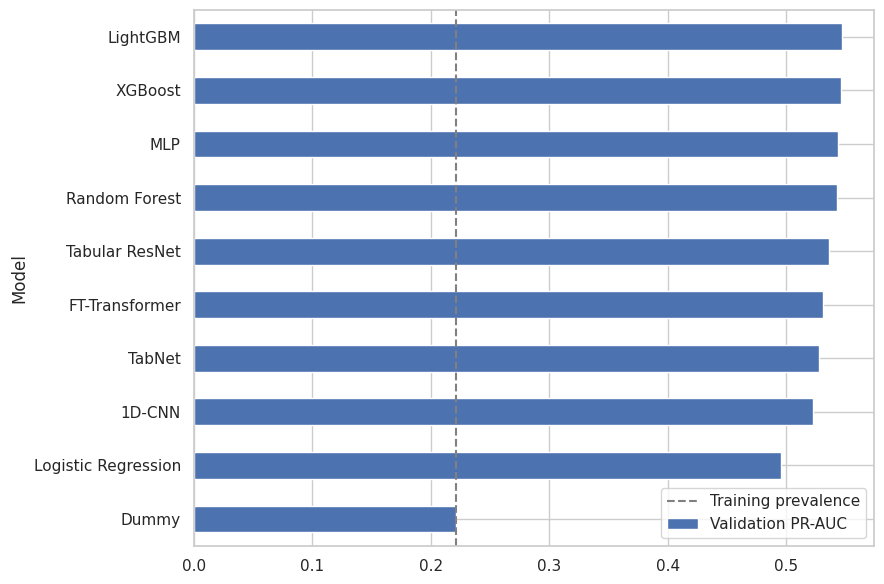

Selected on validation PR-AUC: LightGBM


In [30]:
#Model Selection
comparison=pd.DataFrame(rows).sort_values('Validation PR-AUC',ascending=False).reset_index(drop=True)
display(comparison.round(4))
ax=comparison.sort_values('Validation PR-AUC').plot.barh(x='Model',y='Validation PR-AUC',legend=False,figsize=(9,6))
ax.axvline(y_train.mean(),ls='--',color='gray',label='Training prevalence'); ax.legend(); plt.tight_layout(); plt.show()
champion_name=comparison.iloc[0]['Model']; champion=fitted.get(champion_name,neural.get(champion_name))
print('Selected on validation PR-AUC:',champion_name)

def raw_probability(frame):
    if champion_name in fitted: return champion.predict_proba(frame)[:,1]
    encoded=nn_prep.transform(frame)
    if champion_name=='TabNet': return champion.predict_proba(encoded['dense'])[:,1]
    return torch_probability(champion,encoded,DEVICE)
comparison.to_csv(OUTPUT_DIRS['UCI_Credit_Card']['results']/'validation_model_comparison.csv',index=False)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Calibration Brier before/after: 0.1693 0.1307
F1 threshold selected on calibration data: 0.32


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,ROC-AUC,PR-AUC,Brier,Precision,Recall,F1,MCC,Threshold
0,LightGBM,0.7797,0.5594,0.135,0.5414,0.5373,0.5393,0.4092,0.32


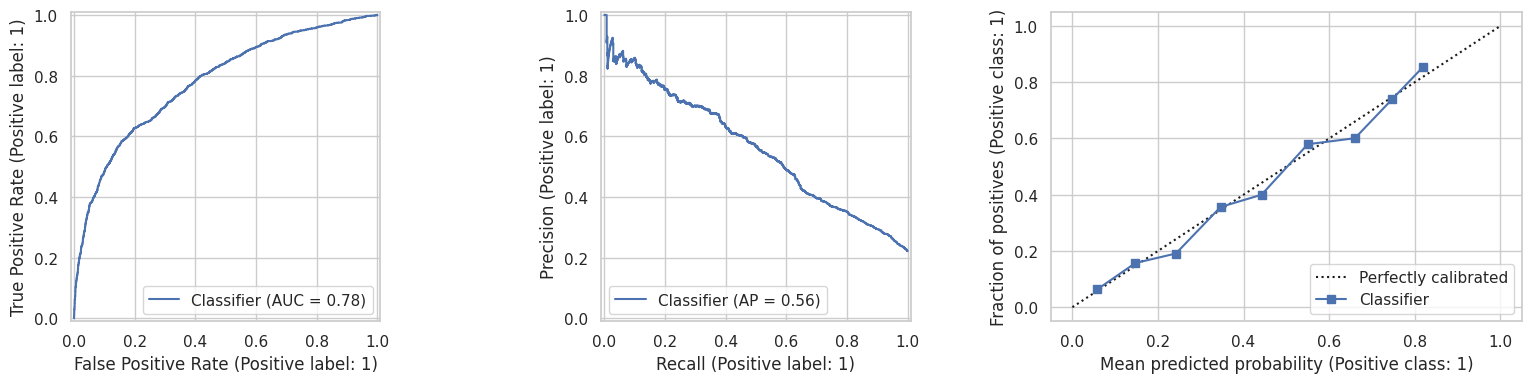

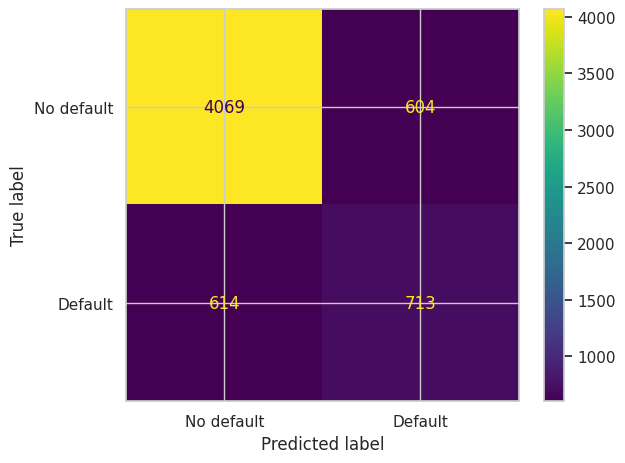

In [31]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.calibration import CalibrationDisplay

from sklearn.linear_model import LogisticRegression
from scipy.special import logit

cal_raw=np.clip(raw_probability(X_cal),1e-6,1-1e-6)
calibrator=LogisticRegression().fit(logit(cal_raw).reshape(-1,1),y_cal)
def calibrated_probability(frame):
    raw=np.clip(raw_probability(frame),1e-6,1-1e-6)
    return calibrator.predict_proba(logit(raw).reshape(-1,1))[:,1]
cal_p=calibrated_probability(X_cal)
threshold_grid=np.r_[.01,np.arange(.02,.99,.01),.99]
threshold=max(threshold_grid,key=lambda t:f1_score(y_cal,cal_p>=t,zero_division=0))
print('Calibration Brier before/after:',round(brier_score_loss(y_cal,cal_raw),4),round(brier_score_loss(y_cal,cal_p),4))
print('F1 threshold selected on calibration data:',round(threshold,3))

# These are the only test-set model calls in the training workflow.
test_raw=raw_probability(X_test); test_p=calibrated_probability(X_test)
test_pred=(test_p>=threshold).astype(int)
test_results=pd.DataFrame([{'Model':champion_name,'ROC-AUC':roc_auc_score(y_test,test_p),
 'PR-AUC':average_precision_score(y_test,test_p),'Brier':brier_score_loss(y_test,test_p),
 'Precision':precision_score(y_test,test_pred,zero_division=0),'Recall':recall_score(y_test,test_pred,zero_division=0),
 'F1':f1_score(y_test,test_pred,zero_division=0),'MCC':matthews_corrcoef(y_test,test_pred),'Threshold':threshold}])
display(test_results.round(4))
test_results.to_csv(OUTPUT_DIRS['UCI_Credit_Card']['results']/'champion_test_metrics.csv',index=False)
fig,axs=plt.subplots(1,3,figsize=(16,4))
RocCurveDisplay.from_predictions(y_test,test_p,ax=axs[0]); PrecisionRecallDisplay.from_predictions(y_test,test_p,ax=axs[1])
CalibrationDisplay.from_predictions(y_test,test_p,n_bins=10,ax=axs[2]); save_and_show(OUTPUT_DIRS['UCI_Credit_Card']['figures']/'roc_pr_calibration.png')
ConfusionMatrixDisplay.from_predictions(y_test,test_pred,display_labels=['No default','Default']); save_and_show(OUTPUT_DIRS['UCI_Credit_Card']['figures']/'champion_confusion_matrix.png')

In [32]:
# A one-time descriptive test comparison after the champion was fixed on validation PR-AUC.
comparison_test=[]
for name in comparison['Model']:
    if name in fitted: p=fitted[name].predict_proba(X_test)[:,1]
    elif name=='TabNet': p=neural[name].predict_proba(nn_prep.transform(X_test)['dense'])[:,1]
    else: p=torch_probability(neural[name],nn_prep.transform(X_test),DEVICE)
    comparison_test.append({'Model':name,'Test PR-AUC':average_precision_score(y_test,p),
                            'Test ROC-AUC':roc_auc_score(y_test,p)})
test_comparison=pd.DataFrame(comparison_test).sort_values('Test PR-AUC',ascending=False)
display(test_comparison.round(4))
test_comparison.to_csv(OUTPUT_DIRS['UCI_Credit_Card']['results']/'descriptive_test_comparison.csv',index=False)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Test PR-AUC,Test ROC-AUC
0,LightGBM,0.5594,0.7797
1,XGBoost,0.5590,0.7810
2,MLP,0.5589,0.7767
5,FT-Transformer,0.5575,0.7812
3,Random Forest,0.5551,0.7775
4,Tabular ResNet,0.5532,0.7706
7,1D-CNN,0.5468,0.7742
6,TabNet,0.5391,0.7705
8,Logistic Regression,0.5193,0.7681
9,Dummy,0.2212,0.5000


In [33]:
# Illustrative error-cost ratios; UCI has no actual exposure, recovery or bank loss data.
from sklearn.metrics import confusion_matrix
cost_rows=[]
for fn_cost in (1,5,10):
    def scenario_cost(labels,probs,t):
        tn,fp,fn,tp=confusion_matrix(labels,probs>=t,labels=[0,1]).ravel()
        return fp+fn_cost*fn
    scenario_threshold=min(threshold_grid,key=lambda t:scenario_cost(y_cal,cal_p,t))
    cost_rows.append({'Assumed FN:FP cost':f'{fn_cost}:1','Calibration-chosen threshold':scenario_threshold,
                      'Test scenario cost':scenario_cost(y_test,test_p,scenario_threshold)})
cost_sensitivity=pd.DataFrame(cost_rows)
display(cost_sensitivity)
cost_sensitivity.to_csv(OUTPUT_DIRS['UCI_Credit_Card']['results']/'hypothetical_cost_sensitivity.csv',index=False)

# Descriptive audit by recorded demographic groups; small cells and confounding limit interpretation.
audit=[]
for col in ('SEX','AGE'):
    groups=X_test[col] if col=='SEX' else pd.cut(X_test[col],bins=[0,30,40,50,120],labels=['<=30','31-40','41-50','51+'])
    for group in groups.dropna().unique():
        mask=np.asarray(groups==group)
        if mask.sum()<50 or len(np.unique(y_test.to_numpy()[mask]))<2: continue
        audit.append({'Field':col,'Group':str(group),'N':int(mask.sum()),
                      'Observed default rate':float(y_test.to_numpy()[mask].mean()),
                      'PR-AUC':average_precision_score(y_test.to_numpy()[mask],test_p[mask]),
                      'Recall':recall_score(y_test.to_numpy()[mask],test_pred[mask],zero_division=0)})
subgroup_audit=pd.DataFrame(audit)
display(subgroup_audit.round(3))
subgroup_audit.to_csv(OUTPUT_DIRS['UCI_Credit_Card']['results']/'subgroup_audit.csv',index=False)

,Assumed FN:FP cost,Calibration-chosen threshold,Test scenario cost
0,1:1,0.41,1120
1,5:1,0.17,3346
2,10:1,0.07,4222


,Field,Group,N,Observed default rate,PR-AUC,Recall
0,SEX,male,2402,0.234,0.556,0.538
1,SEX,female,3598,0.213,0.564,0.537
2,AGE,41-50,1243,0.235,0.566,0.507
3,AGE,31-40,2105,0.210,0.534,0.515
4,AGE,<=30,2181,0.220,0.568,0.570
5,AGE,51+,471,0.244,0.611,0.565


# Phase 5: Explainable AI - SHAP

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

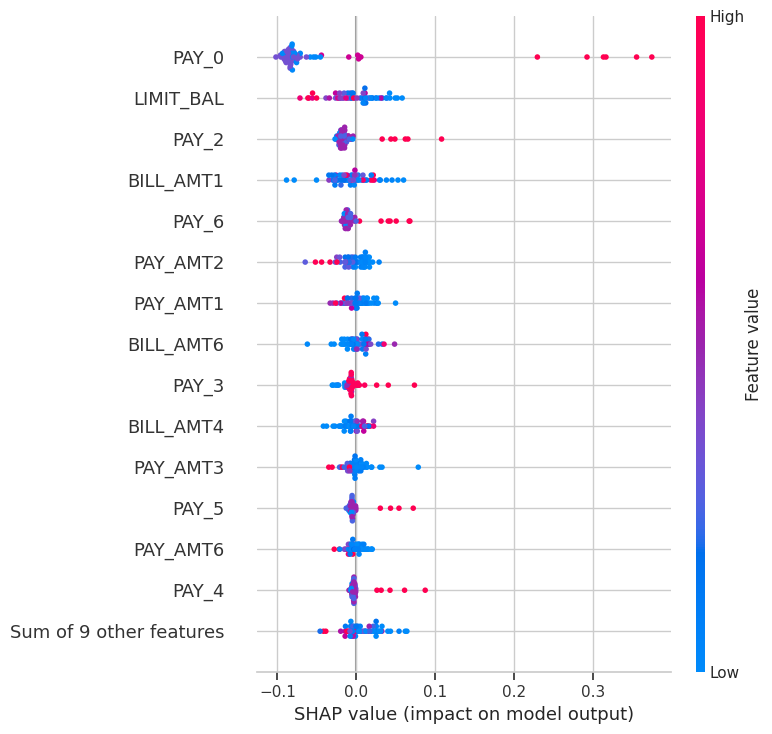

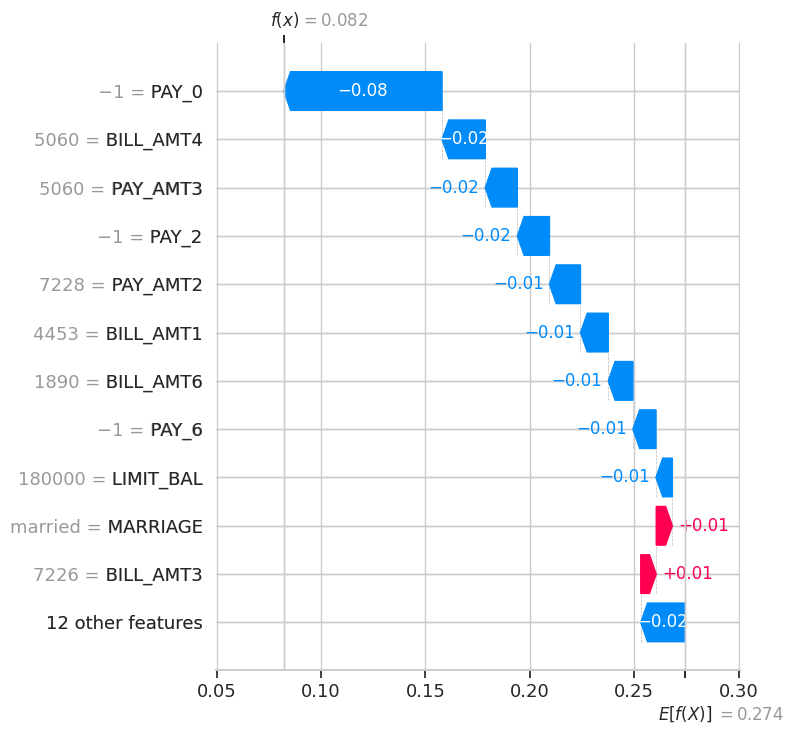

,Mean absolute SHAP (probability points)
PAY_0,0.097244
LIMIT_BAL,0.023194
PAY_2,0.021388
BILL_AMT1,0.020464
PAY_6,0.015107
PAY_AMT2,0.013475
PAY_AMT1,0.012241
BILL_AMT6,0.012006
PAY_3,0.011307
BILL_AMT4,0.010653


In [34]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw_train = uci_raw.loc[X_train.index, RAW_FEATURES].copy()
raw_test = uci_raw.loc[X_test.index, RAW_FEATURES].copy()

background = raw_train.sample(min(30, len(raw_train)), random_state=SEED).copy()

rng = np.random.default_rng(SEED)
explain_indices = rng.choice(
    len(raw_test),
    size=min(60, len(raw_test)),
    replace=False
)
explain_frame = raw_test.iloc[explain_indices].copy()

# Encode categorical features for SHAP
categorical_cols = raw_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

background_shap = background.copy()
explain_shap = explain_frame.copy()
category_maps = {}

for col in categorical_cols:
    categories = raw_train[col].astype(str).dropna().unique().tolist()
    category_maps[col] = dict(enumerate(categories))
    reverse_map = {v: k for k, v in category_maps[col].items()}

    background_shap[col] = background_shap[col].astype(str).map(reverse_map).astype(float)
    explain_shap[col] = explain_shap[col].astype(str).map(reverse_map).astype(float)

for col in RAW_FEATURES:
    if col not in categorical_cols:
        background_shap[col] = pd.to_numeric(background_shap[col], errors="coerce")
        explain_shap[col] = pd.to_numeric(explain_shap[col], errors="coerce")

# Prediction wrapper
def predict_frame(frame):
    frame = pd.DataFrame(frame, columns=RAW_FEATURES).copy()

    for col in categorical_cols:
        codes = (
            pd.to_numeric(frame[col], errors="coerce")
            .round()
            .fillna(0)
            .astype(int)
            .clip(0, len(category_maps[col]) - 1)
        )
        frame[col] = codes.map(category_maps[col])

    model_frame = add_uci_features(frame)[MODEL_FEATURES]
    return np.asarray(calibrated_probability(model_frame)).reshape(-1)

# SHAP
explainer = shap.Explainer(
    predict_frame,
    background_shap,
    algorithm="permutation"
)

explanations = explainer(
    explain_shap,
    max_evals=2 * len(RAW_FEATURES) + 1
)

assert explanations.values.shape == (len(explain_frame), len(RAW_FEATURES))

explanations.data = explain_frame[RAW_FEATURES].to_numpy()
explanations.feature_names = RAW_FEATURES

# Global explanation
shap.plots.beeswarm(explanations, max_display=15, show=False)
save_and_show(
    OUTPUT_DIRS["UCI_Credit_Card"]["shap"] / "global_shap_beeswarm.png"
)

# Local explanation
shap.plots.waterfall(explanations[0], max_display=12, show=False)
save_and_show(
    OUTPUT_DIRS["UCI_Credit_Card"]["shap"] / "local_shap_waterfall.png"
)

# Feature importance
importance = pd.Series(
    np.abs(explanations.values).mean(axis=0),
    index=RAW_FEATURES
).sort_values(ascending=False)

display(
    importance.head(15)
    .rename("Mean absolute SHAP (probability points)")
    .to_frame()
)

importance.rename(
    "mean_absolute_shap_probability_points"
).to_csv(
    OUTPUT_DIRS["UCI_Credit_Card"]["shap"] / "raw_feature_importance.csv"
)

# Phase 6: LLM naration of XAI evidence and evaluation

In [35]:
from dataclasses import dataclass
from collections import Counter
import re

def evidence_for(index):
    row=explain_frame.iloc[index]
    impacts=explanations.values[index]
    chosen=np.argsort(np.abs(impacts))[::-1][:3]
    return {'probability':round(float(calibrated_probability(add_uci_features(explain_frame.iloc[[index]])[MODEL_FEATURES])[0]),4),
            'threshold':round(float(threshold),4),
            'factors':[{'feature':RAW_FEATURES[j],'value':row.iloc[j].item() if hasattr(row.iloc[j],'item') else row.iloc[j],
                        'direction':'higher' if impacts[j]>0 else 'lower',
                        'contribution_probability_points':round(float(impacts[j]),4)} for j in chosen]}

def template_explanation(evidence):
    factors=evidence['factors']
    return {'summary':f"Estimated next-month default probability: {evidence['probability']:.1%}. The comparison threshold is {evidence['threshold']:.1%}. These are associations in the fitted model, not causal claims.",
            'factors':[{'feature':f['feature'],'direction':f['direction']} for f in factors]}

LOCAL_LLM_MODEL = 'Qwen/Qwen2.5-1.5B-Instruct'
_local_llm = None

def load_local_llm():
    global _local_llm
    if _local_llm is None:
        from transformers import AutoTokenizer, AutoModelForCausalLM
        tokenizer = AutoTokenizer.from_pretrained(LOCAL_LLM_MODEL)
        dtype = torch.float16 if torch.cuda.is_available() else torch.float32
        model = AutoModelForCausalLM.from_pretrained(LOCAL_LLM_MODEL, dtype=dtype)
        model.to('cuda' if torch.cuda.is_available() else 'cpu').eval()
        _local_llm = tokenizer, model
    return _local_llm

def llm_explanation(evidence):
    tokenizer, model = load_local_llm()
    factors = evidence['factors']
    lines = '\n'.join(f"{f['feature']}: {f['direction']} ({f['contribution_probability_points']:+.4f} probability points)"
                      for f in factors)
    prompt = (f"Predicted default probability: {evidence['probability']:.1%}\n"
              f"Comparison threshold: {evidence['threshold']:.1%}\n"
              f"SHAP model factors:\n{lines}\n\n"
              'Explain this fitted model in plain English. Use a short Estimate sentence containing both exact percentages, '
              'then one separate line per factor in the form FEATURE: higher or FEATURE: lower. '
              'Use each exact feature code once and its supplied direction. End by saying these are model associations, not causes. '
              'Do not make a lending decision or give financial advice. Keep the entire answer under 100 words.')
    messages = [
        {'role': 'system', 'content': 'Write a concise research explanation from only the supplied SHAP evidence.'},
        {'role': 'user', 'content': prompt},
    ]
    inputs = tokenizer.apply_chat_template(messages, add_generation_prompt=True,
                                           tokenize=True, return_dict=True,
                                           return_tensors='pt').to(model.device)
    with torch.inference_mode():
        output = model.generate(**inputs, max_new_tokens=200, do_sample=False,
                                pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(output[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True).strip()

def evaluate_explanation(answer, evidence):
    empty = {'readable_text':False, 'grounded_features':False,
             'direction_correct':False, 'complete':False, 'numeric_correct':False}
    if not isinstance(answer,str) or not answer.strip(): return empty
    supplied = {f['feature']:f['direction'] for f in evidence['factors']}
    mentioned = {name for name in RAW_FEATURES if re.search(r'(?<![A-Za-z0-9_])'+re.escape(name)+r'(?![A-Za-z0-9_])',answer)}
    grounded = bool(mentioned) and mentioned <= set(supplied)
    complete = mentioned == set(supplied)
    correct = True
    for name,direction in supplied.items():
        pattern = r'(?<![A-Za-z0-9_])'+re.escape(name)+r'(?![A-Za-z0-9_])[^\n]{0,35}\b(higher|lower)\b'
        matches = [m.lower() for m in re.findall(pattern,answer,flags=re.IGNORECASE)]
        if matches != [direction]: correct = False
    numeric = (f"{evidence['probability']:.1%}" in answer and
               f"{evidence['threshold']:.1%}" in answer)
    return {'readable_text':True,'grounded_features':grounded,
            'direction_correct':correct and complete,'complete':complete,'numeric_correct':numeric}

evidence_cases=[evidence_for(i) for i in range(len(explain_frame))]
print('Example evidence:'); display(evidence_cases[0]); display(template_explanation(evidence_cases[0]))


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

Example evidence:


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

{'probability': 0.0822,
 'threshold': 0.32,
 'factors': [{'feature': 'PAY_0',
   'value': -1,
   'direction': 'lower',
   'contribution_probability_points': -0.0757},
  {'feature': 'BILL_AMT4',
   'value': 5060.0,
   'direction': 'lower',
   'contribution_probability_points': -0.0207},
  {'feature': 'PAY_AMT3',
   'value': 5060.0,
   'direction': 'lower',
   'contribution_probability_points': -0.0154}]}

{'summary': 'Estimated next-month default probability: 8.2%. The comparison threshold is 32.0%. These are associations in the fitted model, not causal claims.',
 'factors': [{'feature': 'PAY_0', 'direction': 'lower'},
  {'feature': 'BILL_AMT4', 'direction': 'lower'},
  {'feature': 'PAY_AMT3', 'direction': 'lower'}]}

In [36]:
llm_results = []
llm_errors = []
labels = y_test.iloc[explain_indices].to_numpy()
probabilities = np.array([e['probability'] for e in evidence_cases])
predicted = probabilities >= threshold
selected = []
for actual in (0, 1):
    for guess in (0, 1):
        selected.extend(np.flatnonzero((labels == actual) & (predicted == guess))[:5].tolist())
selected.extend(np.argsort(np.abs(probabilities - threshold))[:10].tolist())
selected = list(dict.fromkeys(selected))
print(f'Evaluating {LOCAL_LLM_MODEL} on {len(selected)} SHAP cases.')
check_names = ['readable_text', 'grounded_features', 'direction_correct', 'complete', 'numeric_correct']
for i in selected:
    record = {'case': i, 'actual': int(labels[i]), 'predicted': int(predicted[i]), 'answer': None}
    try:
        record['answer'] = llm_explanation(evidence_cases[i])
        record.update(evaluate_explanation(record['answer'], evidence_cases[i]))
    except Exception as error:
        record.update(dict.fromkeys(check_names, False))
        llm_errors.append({'case': i, 'error_type': type(error).__name__, 'error': str(error)[:500]})
        print(f'Case {i} failed: {type(error).__name__}: {str(error)[:300]}')
        if _local_llm is None:
            llm_results.append(record)
            break
    llm_results.append(record)
print('Generated text:', sum(r['readable_text'] for r in llm_results),
      '| generation errors:', len(llm_errors), '| attempted:', len(llm_results))
print('Passed all checks:', sum(all(r[k] for k in check_names) for r in llm_results))
if llm_results:
    scores = pd.DataFrame(llm_results).drop(columns='answer')
    display(scores[check_names].mean().rename('pass rate over all attempted cases').to_frame())
    examples = [r['answer'] for r in llm_results if r['readable_text']]
    if examples: display(examples[0])
    scores.to_csv(OUTPUT_DIRS['UCI_Credit_Card']['results'] / 'local_llm_grounding_scores.csv', index=False)
if llm_errors: display(pd.DataFrame(llm_errors).head())
print('Manually review the prose for unsupported claims and readability before reporting findings.')


Evaluating Qwen/Qwen2.5-1.5B-Instruct on 26 SHAP cases.


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Generated text: 26 | generation errors: 0 | attempted: 26
Passed all checks: 5


,pass rate over all attempted cases
readable_text,1.000000
grounded_features,1.000000
direction_correct,0.269231
complete,0.961538
numeric_correct,0.923077


'The predicted default probability is 8.2%, which is below the comparison threshold of 32.0%. The key factors contributing to this low probability include PAY_0 (lower -0.0757 probability point), BILL_AMT4 (lower -0.0207 probability point), and PAY_AMT3 (lower -0.0154 probability point). These associations indicate that borrowers with lower values on these specific features have a reduced likelihood of defaulting.'

Manually review the prose for unsupported claims and readability before reporting findings.


# Phase 7: Deployment

In [62]:
os.environ["ENABLE_LOCAL_LLM"] = "true"

In [63]:
import joblib
source_description = 'UCI Default of Credit Card Clients (Taiwan, 2005); https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients'
joblib.dump(calibrator,ARTIFACTS/'calibrator.joblib')
joblib.dump(background,ARTIFACTS/'shap_background.joblib')
metadata={'champion':champion_name,'threshold':float(threshold),'features':MODEL_FEATURES,'raw_features':RAW_FEATURES,
          'test_metrics':test_results.iloc[0].to_dict(),'source':source_description,
          'seed':SEED,'caution':'Historical UCI research demonstration; not a credit decision tool.'}
if champion_name in fitted:
    metadata['kind']='sklearn'; joblib.dump(champion,ARTIFACTS/'model.joblib')
elif champion_name=='TabNet':
    metadata['kind']='tabnet'; joblib.dump(nn_prep,ARTIFACTS/'nn_preprocessor.joblib')
    champion.save_model(str(ARTIFACTS/'tabnet_model'))  # creates tabnet_model.zip
else:
    metadata['kind']='torch'; joblib.dump(nn_prep,ARTIFACTS/'nn_preprocessor.joblib')
    torch.save(champion.cpu().state_dict(),ARTIFACTS/'model_state.pt')
(ARTIFACTS/'metadata.json').write_text(json.dumps(metadata,indent=2,default=float))
print('Exported:',[p.name for p in ARTIFACTS.iterdir()])

Exported: ['calibrator.joblib', 'shap_background.joblib', 'model.joblib', 'metadata.json']


In [64]:
DEPLOY_DIR = Path('/content/drive/MyDrive/Credit_Risk_Prediction/Credit_Default_Streamlit')
if not DEPLOY_DIR.exists():
    raise FileNotFoundError('Mount Google Drive in Colab first, then rerun this cell.')
APP_SOURCE = 'import json, os\nfrom pathlib import Path\nimport numpy as np\nimport pandas as pd\nimport joblib\nimport streamlit as st\nimport torch\nfrom scipy.special import logit\nfrom credit_risk_runtime import NeuralPreprocessor, make_network, torch_probability, add_uci_features\n\nst.set_page_config(page_title=\'Credit card default | research demo\', layout=\'wide\')\nst.title(\'Credit card default | research demo\')\nROOT=Path(__file__).parent\ndef optional_secret(name,default=None):\n    try: return st.secrets.get(name,os.getenv(name,default))\n    except (FileNotFoundError,KeyError): return os.getenv(name,default)\n@st.cache_resource\ndef load_assets():\n    meta=json.loads((ROOT/\'credit_risk_artifacts/metadata.json\').read_text())\n    calibrator=joblib.load(ROOT/\'credit_risk_artifacts/calibrator.joblib\')\n    background=joblib.load(ROOT/\'credit_risk_artifacts/shap_background.joblib\')\n    kind=meta[\'kind\']; prep=None\n    if kind==\'sklearn\': model=joblib.load(ROOT/\'credit_risk_artifacts/model.joblib\')\n    else:\n        prep=joblib.load(ROOT/\'credit_risk_artifacts/nn_preprocessor.joblib\')\n        if kind==\'tabnet\':\n            from pytorch_tabnet.tab_model import TabNetClassifier\n            model=TabNetClassifier(device_name=\'cpu\',verbose=0)\n            model.load_model(str(ROOT/\'credit_risk_artifacts/tabnet_model.zip\'))\n        else:\n            model=make_network(meta[\'champion\'],prep)\n            model.load_state_dict(torch.load(ROOT/\'credit_risk_artifacts/model_state.pt\',map_location=\'cpu\',weights_only=True))\n            model.eval()\n    return meta,calibrator,background,prep,model\n\ntry:\n    meta,calibrator,background,prep,model=load_assets()\nexcept Exception as error:\n    st.error(\'The model bundle could not be loaded. Check the exported artifact files and dependencies.\')\n    st.exception(error)\n    st.stop()\ndef predict(frame):\n    if meta[\'kind\']==\'sklearn\': raw=model.predict_proba(frame)[:,1]\n    else:\n        encoded=prep.transform(frame)\n        raw=model.predict_proba(encoded[\'dense\'])[:,1] if meta[\'kind\']==\'tabnet\' else torch_probability(model,encoded)\n    return calibrator.predict_proba(logit(np.clip(raw,1e-6,1-1e-6)).reshape(-1,1))[:,1]\n\nst.caption(\'Historical UCI research demonstration. Model output is not a lending decision or personal financial advice.\')\nst.write(\'Selected model:\',meta[\'champion\'],\'| test PR-AUC:\',round(meta[\'test_metrics\'][\'PR-AUC\'],3))\nenable_llm=str(optional_secret(\'ENABLE_LOCAL_LLM\',\'false\')).lower() == \'true\'\ngenerate_llm=enable_llm and st.checkbox(\'Generate local LLM explanation\')\nwith st.form(\'client\'):\n    values={}\n    for col in meta[\'raw_features\']:\n        default=float(background[col].median()) if pd.api.types.is_numeric_dtype(background[col]) else None\n        if col==\'SEX\':\n            values[col]=st.selectbox(col,[\'male\',\'female\'],index=0)\n        elif col==\'EDUCATION\':\n            values[col]=st.selectbox(col,[\'graduate_school\',\'university\',\'high_school\',\'other_or_unknown\'],index=1)\n        elif col==\'MARRIAGE\':\n            values[col]=st.selectbox(col,[\'married\',\'single\',\'other_or_unknown\'],index=0)\n        elif col.startswith(\'PAY_\') and not col.startswith(\'PAY_AMT\'):\n            values[col]=st.number_input(col,min_value=-2,max_value=9,value=int(default),step=1)\n        else:\n            values[col]=st.number_input(col,value=default,step=1.0)\n    submitted=st.form_submit_button(\'Estimate and explain\')\n\nif submitted:\n    raw_row=pd.DataFrame([values])[meta[\'raw_features\']]\n    row=add_uci_features(raw_row)[meta[\'features\']]\n    prob=float(predict(row)[0]); threshold=meta[\'threshold\']\n    import shap\n    shap_background=background[meta[\'raw_features\']].copy()\n    shap_row=raw_row.copy()\n    categories={}\n    for col in (\'SEX\',\'EDUCATION\',\'MARRIAGE\'):\n        labels=sorted(set(shap_background[col].astype(str)) | set(shap_row[col].astype(str)))\n        to_code={label:i for i,label in enumerate(labels)}\n        categories[col]=dict(enumerate(labels))\n        shap_background[col]=shap_background[col].astype(str).map(to_code)\n        shap_row[col]=shap_row[col].astype(str).map(to_code)\n\n    def predict_for_shap(array):\n        frame=pd.DataFrame(array,columns=meta[\'raw_features\']).copy()\n        for col,from_code in categories.items():\n            frame[col]=frame[col].astype(float).round().astype(int).map(from_code)\n        return predict(add_uci_features(frame)[meta[\'features\']])\n\n    assert np.isclose(predict_for_shap(shap_row)[0],prob,atol=1e-8)\n    explainer=shap.Explainer(predict_for_shap,shap_background,algorithm=\'permutation\')\n    result=explainer(shap_row,max_evals=2*len(meta[\'raw_features\'])+1)\n    impacts=result.values[0]; chosen=np.argsort(np.abs(impacts))[::-1][:3]\n    evidence={\'probability\':round(prob,4),\'threshold\':round(threshold,4),\n              \'factors\':[{\'feature\':meta[\'raw_features\'][j],\'value\':raw_row.iloc[0,j].item() if hasattr(raw_row.iloc[0,j],\'item\') else raw_row.iloc[0,j],\n                          \'direction\':\'higher\' if impacts[j]>0 else \'lower\',\n                          \'contribution_probability_points\':round(float(impacts[j]),4)} for j in chosen]}\n    st.session_state[\'last_result\']={\'probability\':prob,\'threshold\':threshold,\'evidence\':evidence}\n\nif \'last_result\' in st.session_state:\n    stored=st.session_state[\'last_result\']\n    prob=stored[\'probability\']; threshold=stored[\'threshold\']; evidence=stored[\'evidence\']\n    st.metric(\'Estimated next-month default probability\',f\'{prob:.1%}\')\n    st.write(f\'Research comparison threshold: {threshold:.1%}. Model flag: {"above" if prob>=threshold else "below"} threshold.\')\n    st.dataframe(pd.DataFrame(evidence[\'factors\']),hide_index=True)\n    st.write(\'These factors describe model attribution relative to a training background; they do not prove causes.\')\n    summary=f"Estimated next-month default probability: {evidence[\'probability\']:.1%}. The comparison threshold is {evidence[\'threshold\']:.1%}. These are associations in the fitted model, not causal claims."\n    if generate_llm:\n        try:\n            from transformers import AutoTokenizer, AutoModelForCausalLM\n            @st.cache_resource\n            def load_local_llm():\n                model_id=\'Qwen/Qwen2.5-1.5B-Instruct\'\n                tokenizer=AutoTokenizer.from_pretrained(model_id)\n                model=AutoModelForCausalLM.from_pretrained(model_id,dtype=torch.float32)\n                model.eval()\n                return tokenizer,model\n            tokenizer,llm=load_local_llm()\n            import re\n            lines=\'\\n\'.join(f"{f[\'feature\']}: {f[\'direction\']} ({f[\'contribution_probability_points\']:+.4f} probability points)"\n                            for f in evidence[\'factors\'])\n            prompt=(f"Predicted default probability: {evidence[\'probability\']:.1%}\\n"\n                    f"Comparison threshold: {evidence[\'threshold\']:.1%}\\n"\n                    f"SHAP model factors:\\n{lines}\\n\\n"\n                    \'Explain in plain English: one Estimate sentence with both exact percentages, \'\n                    \'then one line per factor as FEATURE: higher or FEATURE: lower. \'\n                    \'Use exact codes and directions. These are model associations, not causes. \'\n                    \'No lending advice. Under 100 words.\')\n            messages=[{\'role\':\'system\',\'content\':\'Write a concise explanation using only SHAP evidence.\'},\n                      {\'role\':\'user\',\'content\':prompt}]\n            inputs=tokenizer.apply_chat_template(messages,add_generation_prompt=True,\n                                                 tokenize=True,return_dict=True,return_tensors=\'pt\')\n            with torch.inference_mode():\n                output=llm.generate(**inputs,max_new_tokens=200,do_sample=False,\n                                    pad_token_id=tokenizer.eos_token_id)\n            answer=tokenizer.decode(output[0][inputs[\'input_ids\'].shape[-1]:],skip_special_tokens=True).strip()\n            supplied={f[\'feature\']:f[\'direction\'] for f in evidence[\'factors\']}\n            mentioned={name for name in meta[\'raw_features\'] if re.search(\n                r\'(?<![A-Za-z0-9_])\'+re.escape(name)+r\'(?![A-Za-z0-9_])\',answer)}\n            direction_ok=all([m.lower() for m in re.findall(\n                r\'(?<![A-Za-z0-9_])\'+re.escape(name)+r\'(?![A-Za-z0-9_])[^\\n]{0,35}\\b(higher|lower)\\b\',\n                answer,flags=re.IGNORECASE)]==[direction] for name,direction in supplied.items())\n            valid=(bool(answer) and mentioned==set(supplied) and direction_ok and\n                   f"{evidence[\'probability\']:.1%}" in answer and\n                   f"{evidence[\'threshold\']:.1%}" in answer)\n            if valid: st.write(answer)\n            else: st.warning(\'Local LLM failed grounding checks; showing template.\'); st.write(summary)\n        except Exception as error:\n            st.warning(\'Local LLM unavailable; showing template.\'); st.write(summary)\n    else: st.write(summary)\n'
(DEPLOY_DIR / 'app.py').write_text(APP_SOURCE)
print('Streamlit app:', DEPLOY_DIR / 'app.py')


Streamlit app: /content/drive/MyDrive/Credit_Risk_Prediction/Credit_Default_Streamlit/app.py


In [65]:
DEPLOY_DIR = Path('/content/drive/MyDrive/Credit_Risk_Prediction/Credit_Default_Streamlit')
ARTIFACTS = DEPLOY_DIR / 'credit_risk_artifacts'
if not (ARTIFACTS / 'metadata.json').exists():
    raise FileNotFoundError('Mount Google Drive and export the trained model before building the ZIP.')
(DEPLOY_DIR / 'requirements.txt').write_text('numpy<3\npandas\nscipy\nscikit-learn\nxgboost\nlightgbm\ntorch\npytorch-tabnet\nshap\nstreamlit\ntransformers\naccelerate\njoblib\n')
from zipfile import ZipFile, ZIP_DEFLATED
with ZipFile(DEPLOY_DIR / 'credit_risk_streamlit_bundle.zip','w',ZIP_DEFLATED) as archive:
    for item in [DEPLOY_DIR / 'app.py', DEPLOY_DIR / 'credit_risk_runtime.py', DEPLOY_DIR / 'requirements.txt', *ARTIFACTS.glob('*')]:
        archive.write(item,item.relative_to(DEPLOY_DIR).as_posix())
print('Deployment package created: credit_risk_streamlit_bundle.zip')
print('Local command: streamlit run app.py')
try:
    from google.colab import files
    files.download(str(DEPLOY_DIR / 'credit_risk_streamlit_bundle.zip'))
except ImportError:
    print('Bundle saved to Google Drive:',DEPLOY_DIR / 'credit_risk_streamlit_bundle.zip')


Deployment package created: credit_risk_streamlit_bundle.zip
Local command: streamlit run app.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
import subprocess
import sys
import time
from pathlib import Path
import requests

APP_FILE = DEPLOY_DIR / 'app.py'
assert APP_FILE.exists(), 'Run the app-export cell above first.'
assert (DEPLOY_DIR / 'credit_risk_artifacts' / 'metadata.json').exists(), 'Run the model-export cell above first.'
STREAMLIT_LOG = Path('/content/streamlit.log')
subprocess.run(['fuser', '-k', '8501/tcp'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
streamlit_log = STREAMLIT_LOG.open('w')
streamlit_process = subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', str(APP_FILE),
     '--server.address', '0.0.0.0', '--server.port', '8501',
     '--server.headless', 'true', '--server.enableCORS', 'false',
     '--server.enableXsrfProtection', 'false', '--browser.gatherUsageStats', 'false'],
    cwd=DEPLOY_DIR, stdout=streamlit_log, stderr=subprocess.STDOUT,
)
for _ in range(20):
    if streamlit_process.poll() is not None:
        break
    try:
        response = requests.get('http://127.0.0.1:8501/_stcore/health', timeout=2)
        if response.ok:
            print('Streamlit is running on port 8501. PID:', streamlit_process.pid)
            break
    except requests.RequestException:
        pass
    time.sleep(1)
else:
    raise RuntimeError('Streamlit did not start. Log:\n' + STREAMLIT_LOG.read_text()[-4000:])
if streamlit_process.poll() is not None:
    raise RuntimeError('Streamlit exited. Log:\n' + STREAMLIT_LOG.read_text()[-4000:])


Streamlit is running on port 8501. PID: 40921


In [67]:
import re
from IPython.display import HTML, display

assert requests.get('http://127.0.0.1:8501/_stcore/health', timeout=5).ok, STREAMLIT_LOG.read_text()[-4000:]
cloudflared = Path('/usr/local/bin/cloudflared')
if not cloudflared.exists():
    subprocess.run(['wget', '-q',
                    'https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64',
                    '-O', str(cloudflared)], check=True)
    cloudflared.chmod(0o755)
if 'tunnel_process' in globals() and tunnel_process.poll() is None:
    tunnel_process.terminate()
CLOUDFLARE_LOG = Path('/content/cloudflared.log')
tunnel_log = CLOUDFLARE_LOG.open('w')
tunnel_process = subprocess.Popen(
    [str(cloudflared), 'tunnel', '--url', 'http://127.0.0.1:8501', '--no-autoupdate'],
    stdout=tunnel_log, stderr=subprocess.STDOUT,
)
public_url = None
for _ in range(45):
    time.sleep(1)
    match = re.search(r'https://[a-zA-Z0-9-]+\.trycloudflare\.com', CLOUDFLARE_LOG.read_text())
    if match:
        public_url = match.group(0)
        break
    if tunnel_process.poll() is not None:
        break
if not public_url:
    raise RuntimeError('Tunnel URL unavailable. Log:\n' + CLOUDFLARE_LOG.read_text()[-4000:])
print('Open this temporary app URL:', public_url)
display(HTML(f'<a href="{public_url}" target="_blank">Open Credit Default Streamlit App</a>'))


Open this temporary app URL: https://omaha-nominated-cloudy-doing.trycloudflare.com
